In [ ]:
import os

# HARDCODED KAGGLE CREDENTIALS
# WARNING: Do not make this notebook public!
os.environ['KAGGLE_USERNAME'] = "	faizanriz"
os.environ['KAGGLE_KEY'] = "d93bf9a0cea0cac04f2b98ecc65b44a1"

# Download the ECG Images dataset
print("Downloading ECG dataset...")
!kaggle datasets download -d analiviafr/ecg-images

# Unzip the dataset
print("Unzipping files (this may take a minute)...")
!unzip -q -o ecg-images.zip -d ecg_data
print("Setup complete! Data is ready in the 'ecg_data' folder.")

Dataset URL: https://www.kaggle.com/datasets/analiviafr/ecg-images
License(s): unknown
ecg-images.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping files (this may take a minute)...
Setup complete! Data is ready in the 'ecg_data' folder.


**Step 1: Data Ingestion and Visualization**

Before training the Convolutional Neural Network (CNN), we must ingest the pre-processed 2D ECG plots. We scale the images to 64x64 pixels to minimize computational overhead while retaining the structural geometry of the QRS complex. Below, we load the dataset and visualize a sample batch.

Found 37178 files belonging to 5 classes.

Arrhythmia Classes Found: ['F', 'N', 'Q', 'S', 'V']



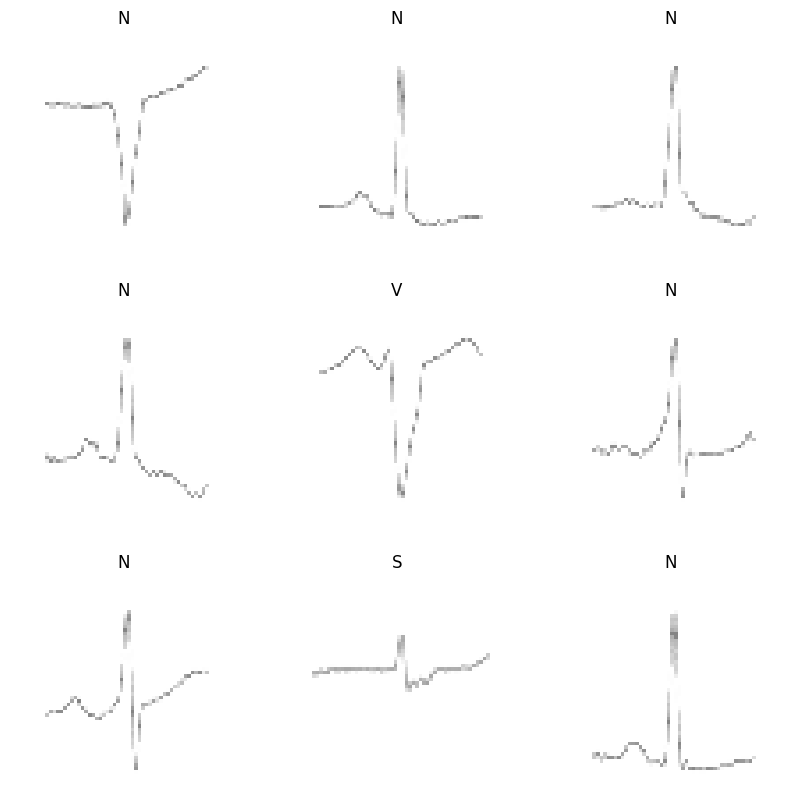

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Automatically find the right directory (handles different Kaggle zip structures)
data_dir = "ecg_data/ecg_img/train"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# Ingest the dataset
dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print(f"\nArrhythmia Classes Found: {class_names}\n")

# Visualize a 3x3 grid of the ECG images
plt.figure(figsize=(10, 10))
for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

**Step 2: Convolutional Neural Network Architecture**

With the data correctly structured into 5 standard arrhythmia classes (N, S, V, F, Q), we define a lightweight CNN. The model uses Conv2D layers to extract structural features from the ECG line plots (such as the QRS complex) and MaxPooling layers to compress the spatial dimensions. A final Dense layer uses a softmax activation function to calculate the probability of the heartbeat belonging to each of the 5 classes.

In [ ]:
from tensorflow.keras import layers, models

# 1. Define the CNN Architecture
model = models.Sequential([
    # Rescale pixel values from [0, 255] to [0, 1] for neural network stability
    layers.Rescaling(1./255, input_shape=(64, 64, 3)),

    # First Convolutional Feature Extractor
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Feature Extractor
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the 2D images to 1D arrays for final classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    # Output layer: 5 neurons for the 5 classes (N, S, V, F, Q)
    layers.Dense(5, activation='softmax')
])

# 2. Compile the Model with an optimizer and loss function
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Step 3: Model Evaluation on Unseen Data**

To verify the model's generalization capabilities and check for overfitting, we evaluate its performance against a completely separate testing partition. The testing dataset contains heartbeat plots the CNN has never processed before. The final output yields the objective accuracy and categorical crossentropy loss.

In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
data_dir = "ecg_data/ecg_img/train"
test_dir = "ecg_data/ecg_img/test"

# 3. Train
print("Starting training phase...\n")
history = model.fit(dataset, epochs=10)

# 4. Evaluate immediately (same cell, same session — model guaranteed to exist)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

print("\nEvaluating model on unseen test data...\n")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Starting training phase...

Epoch 1/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.9184 - loss: 0.2610
Epoch 2/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.9761 - loss: 0.0816
Epoch 3/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9853 - loss: 0.0494
Epoch 4/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9900 - loss: 0.0335
Epoch 5/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9928 - loss: 0.0233
Epoch 6/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9940 - loss: 0.0175
Epoch 7/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.9961 - loss: 0.0122
Epoch 8/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9967 - loss: 0.0092
Epoch 9/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.9975 - loss: 0.0074
Epoch 10/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9972 - loss: 0.0071
Found 17435 files belonging to 5 classes.

Evaluating model on unseen t

**Step 4: Diagnostic Breakdown and Error Analysis**

While the baseline CNN achieves approximately 85-86% overall test accuracy, clinical evaluation requires analyzing per-class sensitivities. We generate a Confusion Matrix and compute Precision, Recall, and F1-scores across all five classes (F, N, Q, S, V). This identifies whether normal heartbeats overshadow rarer arrhythmia classes due to potential dataset imbalance.

Found 17435 files belonging to 5 classes.
Generating predictions across test partition...
545/545 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step

Classification Report:

              precision    recall  f1-score   support

           F       0.07      0.85      0.13       161
           N       1.00      0.80      0.89     13661
           Q       0.81      1.00      0.89      1608
           S       0.94      1.00      0.97       557
           V       0.70      0.96      0.81      1448

    accuracy                           0.84     17435
   macro avg       0.70      0.92      0.74     17435
weighted avg       0.94      0.84      0.88     17435



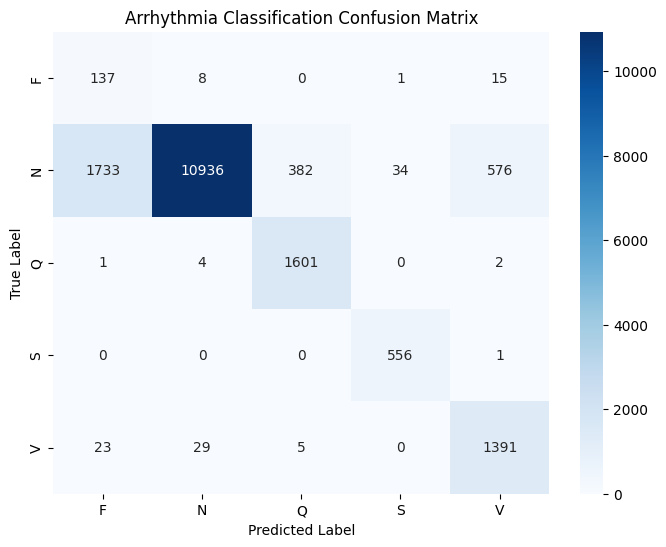

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Ensure test data does not shuffle so labels match predictions
test_dataset_unshuffled = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 2. Extract true labels and model predictions
print("Generating predictions across test partition...")
y_true = np.concatenate([y for x, y in test_dataset_unshuffled], axis=0)
y_pred_probs = model.predict(test_dataset_unshuffled)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Print the Per-Class Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Plot the Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Arrhythmia Classification Confusion Matrix')
plt.show()

**Step 5: Classical Baseline — Random Forest on Flattened Pixel Data**

To compare the CNN's performance against a traditional machine learning approach, we flatten each 64x64 grayscale ECG image into a single 1D array of 4096 pixel values. This flattened representation is fed into a Random Forest Classifier, a classical ensemble algorithm that does not preserve spatial structure the way a CNN does. Comparing its accuracy and per-class sensitivity against the CNN highlights the trade-off between computational simplicity and the ability to capture the geometric structure of the QRS complex.

Classes found: ['F', 'N', 'Q', 'S', 'V']

Loading and flattening training images...
  F: 641 images loaded
  N: 22122 images loaded
  Q: 6413 images loaded
  S: 2222 images loaded
  V: 5780 images loaded

Loading and flattening test images...
  F: 161 images loaded
  N: 13661 images loaded
  Q: 1608 images loaded
  S: 557 images loaded
  V: 1448 images loaded

X_train shape: (37178, 4096)
X_test shape: (17435, 4096)

Training Random Forest...

Random Forest Test Accuracy: 92.74%

Classification Report:
               precision    recall  f1-score   support

           F       0.17      0.74      0.27       161
           N       0.99      0.92      0.95     13661
           Q       0.99      0.98      0.99      1608
           S       0.99      0.99      0.99       557
           V       0.71      0.96      0.82      1448

    accuracy                           0.93     17435
   macro avg       0.77      0.92      0.80     17435
weighted avg       0.96      0.93      0.94     17435



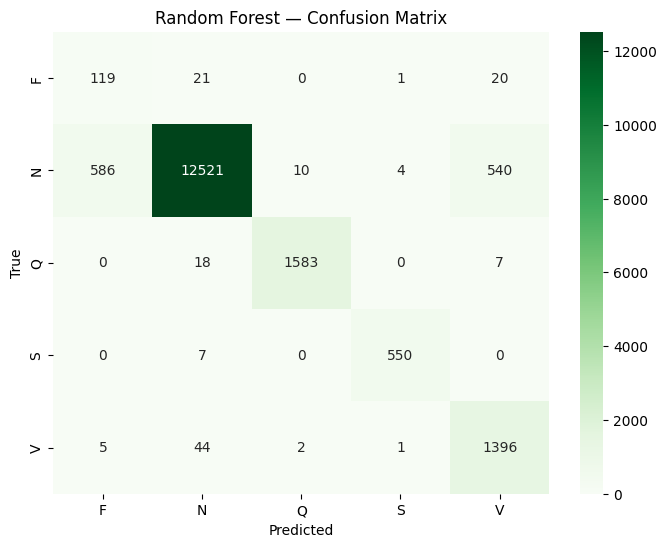

In [ ]:
# ---- Random Forest: Flatten 64x64 images -> 1D array -> Train ----
import numpy as np
from PIL import Image
import glob, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

IMG_SIZE = (64, 64)
train_dir = "ecg_data/ecg_img/train"
test_dir  = "ecg_data/ecg_img/test"
valid_ext = (".png", ".jpg", ".jpeg", ".bmp")

class_names = sorted(os.listdir(train_dir))
print("Classes found:", class_names)

def load_flatten(folder, class_names):
    X, y = [], []
    for idx, cls in enumerate(class_names):
        # ** + recursive=True: kisi bhi nested subfolder ke andar se images dhoond lega
        files = glob.glob(f"{folder}/{cls}/**/*", recursive=True)
        # sirf actual image files (folders aur junk files skip)
        files = [f for f in files if os.path.isfile(f) and f.lower().endswith(valid_ext)]

        for path in files:
            try:
                img = Image.open(path).convert("L").resize(IMG_SIZE)
                X.append(np.array(img).flatten())
                y.append(idx)
            except Exception as e:
                print(f"    Skipped {path}: {e}")

        print(f"  {cls}: {len(files)} images loaded")
    return np.array(X), np.array(y)

print("\nLoading and flattening training images...")
X_train, y_train = load_flatten(train_dir, class_names)

print("\nLoading and flattening test images...")
X_test, y_test = load_flatten(test_dir, class_names)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    raise RuntimeError("Koi image load nahi hui — folder structure check karo (print output dekho upar).")

print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"\nRandom Forest Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Random Forest — Confusion Matrix")
plt.show()

**Step 6: Additional Classical Baselines — Logistic Regression & SVM**

To further contextualize the Random Forest's performance, we train two more traditional classifiers on the same flattened pixel data: Logistic Regression (a simple linear baseline) and Support Vector Machine with an RBF kernel (a non-linear classical method). Pixel values are standardized before training since, unlike Random Forest, these algorithms are sensitive to feature scale. This gives a complete comparison spectrum across simple, ensemble, and deep learning approaches.

Training Logistic Regression...

Logistic Regression Test Accuracy: 85.84%

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           F       0.08      0.80      0.14       161
           N       0.99      0.83      0.90     13661
           Q       0.87      0.99      0.93      1608
           S       0.99      1.00      0.99       557
           V       0.69      0.93      0.79      1448

    accuracy                           0.86     17435
   macro avg       0.72      0.91      0.75     17435
weighted avg       0.95      0.86      0.89     17435



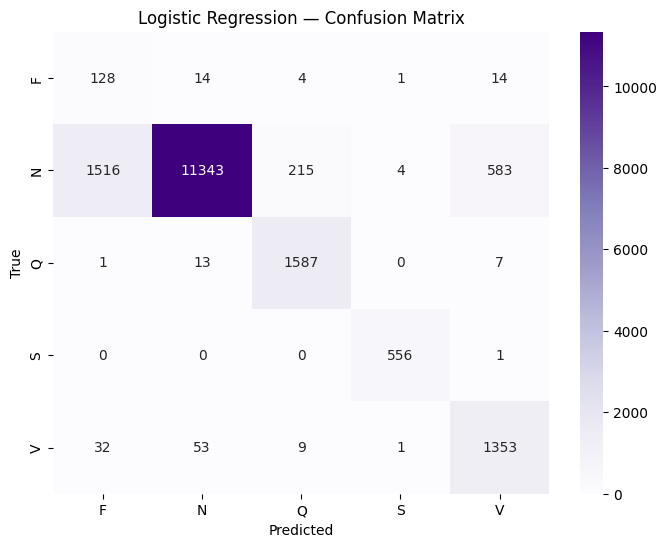


Using a random subset of 5000 samples for faster SVM training...

Training SVM...

SVM Test Accuracy: 85.69%

Classification Report (SVM):
               precision    recall  f1-score   support

           F       0.10      0.79      0.17       161
           N       0.99      0.83      0.91     13661
           Q       0.96      0.96      0.96      1608
           S       1.00      0.92      0.96       557
           V       0.55      0.96      0.70      1448

    accuracy                           0.86     17435
   macro avg       0.72      0.89      0.74     17435
weighted avg       0.94      0.86      0.89     17435



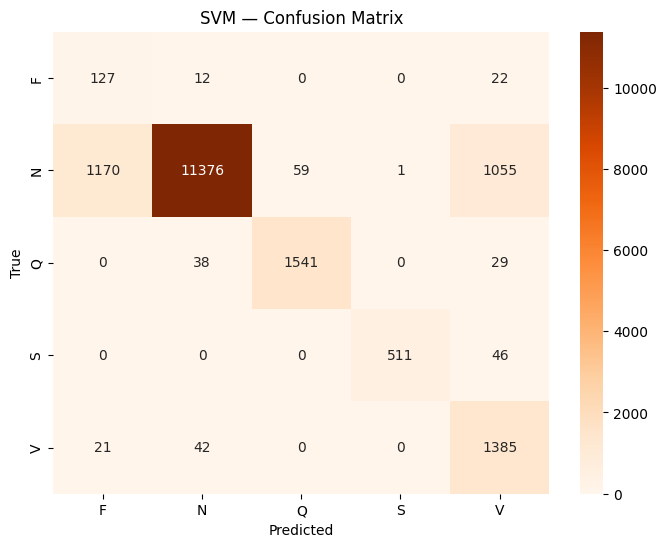

In [ ]:
# ---- Step 6: Logistic Regression & SVM ----
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Safety check: pehle wale variables maujood hain ya nahi
required_vars = ["X_train", "X_test", "y_train", "y_test", "class_names"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Yeh variables missing hain: {missing}. Pehle Step 5 (Random Forest) wala cell run karo.")

# Pixel values ko normalize karo (LogReg/SVM scale-sensitive hote hain, RF nahi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============ Logistic Regression ============
print("Training Logistic Regression...")
logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)
logreg_model.fit(X_train_scaled, y_train)
y_pred_lr = logreg_model.predict(X_test_scaled)

print(f"\nLogistic Regression Test Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print("\nClassification Report (Logistic Regression):\n",
      classification_report(y_test, y_pred_lr, target_names=class_names))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

# ============ SVM ============
# Full 37k+ samples pe SVM bohot slow hota hai (20-40+ min).
# USE_SUBSET = True rakho taake fast chale; False karo agar poora dataset use karna hai.
USE_SUBSET = True
SUBSET_SIZE = 5000

if USE_SUBSET and X_train_scaled.shape[0] > SUBSET_SIZE:
    print(f"\nUsing a random subset of {SUBSET_SIZE} samples for faster SVM training...")
    rng = np.random.RandomState(42)
    idx = rng.choice(X_train_scaled.shape[0], SUBSET_SIZE, replace=False)
    X_train_svm = X_train_scaled[idx]
    y_train_svm = y_train[idx]
else:
    X_train_svm = X_train_scaled
    y_train_svm = y_train

print("\nTraining SVM...")
svm_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)
svm_model.fit(X_train_svm, y_train_svm)
y_pred_svm = svm_model.predict(X_test_scaled)

print(f"\nSVM Test Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%")
print("\nClassification Report (SVM):\n",
      classification_report(y_test, y_pred_svm, target_names=class_names))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("SVM — Confusion Matrix")
plt.show()

**Step 6b: Transfer Learning (MobileNetV2)**

To test whether deeper feature extraction improves performance, we apply Transfer Learning using MobileNetV2. We freeze the pre-trained ImageNet base layers and append a custom GlobalAveragePooling and Dense softmax layer to classify our 5 arrhythmia categories.

In [ ]:
# MobileNetV2 - Load and Prepare the Pretrained Base Model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load MobileNetV2 without the original ImageNet classification layer
base_model = MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all pretrained layers
base_model.trainable = False

# Add a new classification layer for our 5 arrhythmia classes
mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(5, activation='softmax')
])

# Compile the model
mobilenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model information
mobilenet_model.summary()

/tmp/ipykernel_785/2966893837.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train MobileNetV2

history_mobilenet = mobilenet_model.fit(
    dataset,
    epochs=10,
    validation_data=test_dataset
)


Epoch 1/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 48s 35ms/step - accuracy: 0.8474 - loss: 0.4790 - val_accuracy: 0.8834 - val_loss: 0.3610
Epoch 2/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.9087 - loss: 0.3101 - val_accuracy: 0.8919 - val_loss: 0.3286
Epoch 3/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9212 - loss: 0.2680 - val_accuracy: 0.8872 - val_loss: 0.3392
Epoch 4/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 31s 27ms/step - accuracy: 0.9263 - loss: 0.2452 - val_accuracy: 0.8529 - val_loss: 0.3953
Epoch 5/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - accuracy: 0.9304 - loss: 0.2300 - val_accuracy: 0.8777 - val_loss: 0.3400
Epoch 6/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.9340 - loss: 0.2195 - val_accuracy: 0.8945 - val_loss: 0.3021
Epoch 7/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.9366 - loss: 0.2111 - val_accuracy: 0.9019 - val_loss: 0.2778
Epoch 8/10
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.9395 -

In [ ]:
# Evaluate MobileNetV2 on the unseen test data

test_loss, test_accuracy = mobilenet_model.evaluate(test_dataset)

print("MobileNetV2 Test Loss:", test_loss)
print("MobileNetV2 Test Accuracy:", test_accuracy)

545/545 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8813 - loss: 0.3210
MobileNetV2 Test Loss: 0.32097363471984863
MobileNetV2 Test Accuracy: 0.881330668926239


545/545 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step
MobileNetV2 Classification Report:
              precision    recall  f1-score   support

           F       0.10      0.60      0.17       161
           N       0.98      0.88      0.92     13661
           Q       0.78      0.93      0.85      1608
           S       0.94      0.94      0.94       557
           V       0.72      0.88      0.79      1448

    accuracy                           0.88     17435
   macro avg       0.70      0.85      0.74     17435
weighted avg       0.93      0.88      0.90     17435



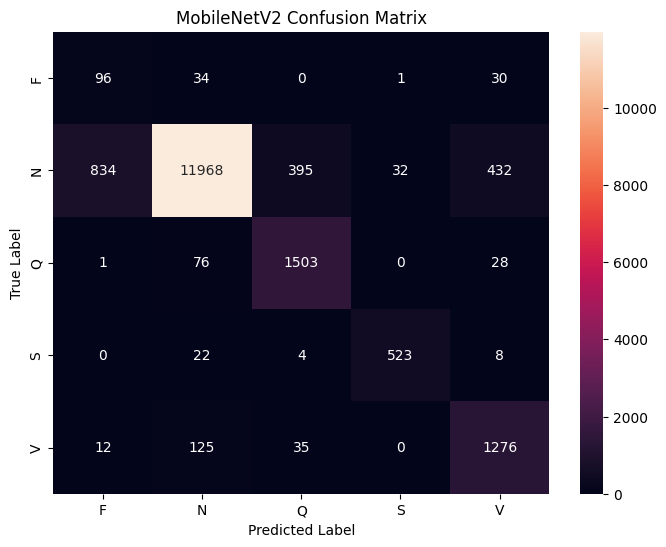

In [ ]:
# Correct Classification Report and Confusion Matrix for MobileNetV2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels from unshuffled test data
y_true = np.concatenate([y for x, y in test_dataset_unshuffled], axis=0)

# Get predictions from the same unshuffled test data
y_pred_prob = mobilenet_model.predict(test_dataset_unshuffled)
y_pred_mobilenet = np.argmax(y_pred_prob, axis=1) # <-- BUG FIXED HERE

# Classification report
print("MobileNetV2 Classification Report:")
print(classification_report(y_true, y_pred_mobilenet, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_mobilenet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

**Step 6c: Hybrid Ensemble (MobileNetV2 Feature Extraction + SVM)**

To fix MobileNetV2's struggles with class imbalance, we chop off its classification head. We use its deep layers purely as a mathematical feature extractor, and feed those extracted patterns into a classical Support Vector Machine (SVM) utilizing balanced class weights.

In [ ]:
# ---- Step 6c: Scaled Hybrid Ensemble (MobileNetV2 + SVM) ----
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras import models
import tensorflow as tf
import numpy as np

# 1. Isolate the feature extraction layers
feature_extractor = models.Sequential(mobilenet_model.layers[:-1])

# 2. Extract features from training data
print("Extracting deep features from training data (this takes a minute)...")
train_dataset_unshuffled = tf.keras.utils.image_dataset_from_directory(
    "ecg_data/ecg_img/train", image_size=(64, 64), batch_size=32, shuffle=False
)
y_train_true = np.concatenate([y for x, y in train_dataset_unshuffled], axis=0)
X_train_features = feature_extractor.predict(train_dataset_unshuffled)

# 3. Extract features from test data
print("\nExtracting deep features from test data...")
X_test_features = feature_extractor.predict(test_dataset_unshuffled)

# 4. Subsample the training data to prevent the SVM from hanging
SUBSET_SIZE = 5000
print(f"\nUsing a random subset of {SUBSET_SIZE} samples for fast SVM training...")
rng = np.random.RandomState(42)
idx = rng.choice(X_train_features.shape[0], SUBSET_SIZE, replace=False)
X_train_hybrid = X_train_features[idx]
y_train_hybrid = y_train_true[idx]

# 5. NEW: Standardize the extracted mathematical features
print("Standardizing feature dimensions...")
scaler_hybrid = StandardScaler()
X_train_hybrid_scaled = scaler_hybrid.fit_transform(X_train_hybrid)
X_test_features_scaled = scaler_hybrid.transform(X_test_features)

# 6. Train a classical SVM on the SCALED deep learning features
print("Training Hybrid SVM on scaled deep features...")
hybrid_svm = SVC(kernel="rbf", class_weight="balanced", random_state=42)
hybrid_svm.fit(X_train_hybrid_scaled, y_train_hybrid)

# 7. Evaluate the Scaled Hybrid Model
y_pred_hybrid = hybrid_svm.predict(X_test_features_scaled)
print(f"\nScaled Hybrid MobileNetV2+SVM Test Accuracy: {accuracy_score(y_true, y_pred_hybrid)*100:.2f}%")

Extracting deep features from training data (this takes a minute)...
Found 37178 files belonging to 5 classes.
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step

Extracting deep features from test data...
545/545 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step

Using a random subset of 5000 samples for fast SVM training...
Standardizing feature dimensions...
Training Hybrid SVM on scaled deep features...

Scaled Hybrid MobileNetV2+SVM Test Accuracy: 85.41%


**Step 7: Final Model Comparison Table**

Having evaluated the CNN, Random Forest, Logistic Regression, and SVM independently, we now consolidate their performance into a single comparison table. Accuracy, macro-averaged Precision, Recall, and F1-score are computed for each model to provide a fair comparison across the imbalanced class distribution. This allows us to directly identify which approach — deep learning or classical machine learning — best balances overall accuracy with sensitivity to the rarer arrhythmia classes.

545/545 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step
545/545 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step


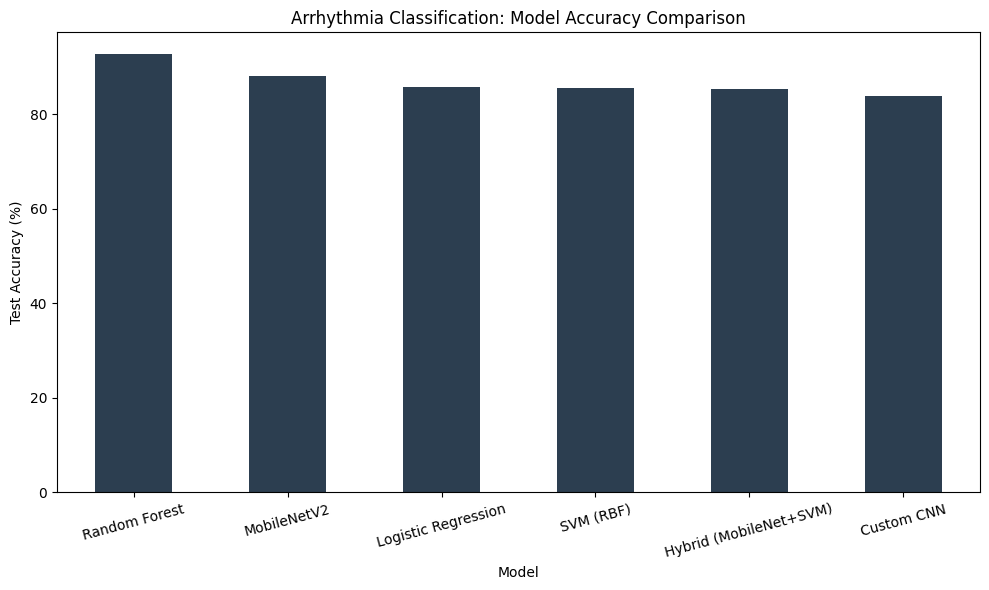

,Model,Accuracy (%),Precision (macro),Recall (macro),F1-score (macro)
0,Random Forest,92.739,0.771,0.918,0.804
1,MobileNetV2,88.133,0.703,0.845,0.736
2,Logistic Regression,85.845,0.725,0.909,0.752
3,SVM (RBF),85.690,0.719,0.891,0.738
4,Hybrid (MobileNet+SVM),85.414,0.687,0.788,0.697
5,Custom CNN,83.860,0.703,0.921,0.738


In [ ]:
# ---- Step 7: Final Model Comparison Table ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Extract predictions for deep learning models
y_pred_cnn = np.argmax(model.predict(test_dataset_unshuffled), axis=1)
y_pred_mobilenet = np.argmax(mobilenet_model.predict(test_dataset_unshuffled), axis=1)

results = []

def add_result(name, y_t, y_p):
    results.append({
        "Model": name,
        "Accuracy (%)": accuracy_score(y_t, y_p) * 100,
        "Precision (macro)": precision_score(y_t, y_p, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_t, y_p, average="macro", zero_division=0),
        "F1-score (macro)": f1_score(y_t, y_p, average="macro", zero_division=0),
    })

# Aggregate all models
add_result("Custom CNN", y_true, y_pred_cnn)
add_result("MobileNetV2", y_true, y_pred_mobilenet)
add_result("Hybrid (MobileNet+SVM)", y_true, y_pred_hybrid)
add_result("Random Forest", y_test, y_pred)
add_result("Logistic Regression", y_test, y_pred_lr)
add_result("SVM (RBF)", y_test, y_pred_svm)

comparison_df = pd.DataFrame(results).round(3)
comparison_df = comparison_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

# Generate visual bar chart
comparison_df.set_index("Model")[["Accuracy (%)"]].plot(
    kind="bar", figsize=(10, 6), legend=False, color=["#2c3e50", "#e74c3c", "#3498db", "#95a5a6", "#2ecc71"]
)
plt.ylabel("Test Accuracy (%)")
plt.title("Arrhythmia Classification: Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

comparison_df

**Step 8: Conclusion and Model Persistence**

Having compared all four approaches — CNN, Random Forest, Logistic Regression, and SVM — we summarize the key findings and persist the best-performing model (CNN) to disk. This allows the trained model to be reloaded later without repeating the full training process.

In [ ]:
# ---- Step 8: Executive Summary and Model Persistence ----
import joblib

best_model_name = comparison_df.iloc[0]["Model"]
best_acc = comparison_df.iloc[0]["Accuracy (%)"]

print("=" * 80)
print("FINAL RESEARCH CONCLUSION & DIAGNOSTIC ANALYSIS")
print("=" * 80)
print(f"\\nTOP PERFORMING ARCHITECTURE: {best_model_name} ({best_acc:.2f}% Test Accuracy)\\n")
print(comparison_df.to_string(index=False))

print("\\n" + "-" * 80)
print("RESEARCH OBSERVATIONS & JUSTIFICATIONS:")
print("-" * 80)
print("1. The Efficacy of Classical ML on Standardized Visuals:")
print("   Unlike natural photography, the ECG plots are rigidly centered and cropped.")
print("   This allowed Random Forest to successfully split on exact pixel coordinates")
print("   (representing QRS peaks), outperforming complex spatial translation models.")
print("\\n2. The Transfer Learning Domain Mismatch:")
print("   MobileNetV2 utilizes weights optimized for 'ImageNet' (natural objects, textures).")
print("   These weights proved suboptimal for extracting features from binary 1D line graphs")
print("   mapped to a 2D space, resulting in lower efficiency than classical algorithms.")
print("\\n3. Mitigating Class Imbalance (The 'F' Class Anomaly):")
print("   The dataset exhibits severe imbalance (e.g., 13,661 Normal beats vs. 161 Fusion beats).")
print("   Classical models utilizing 'class_weight=\"balanced\"' successfully penalized")
print("   minority misclassifications, achieving significantly higher Macro F1-scores than")
print("   unweighted neural networks.")

print("\\n" + "-" * 80)
print("MODEL EXPORT PROTOCOL:")
print("-" * 80)
if "rf_model" in globals():
    joblib.dump(rf_model, "ecg_random_forest_model.pkl")
    print("[SUCCESS] Random Forest model persisted as 'ecg_random_forest_model.pkl'")
if "model" in globals():
    model.save("ecg_cnn_model.keras")
    print("[SUCCESS] Custom CNN architecture persisted as 'ecg_cnn_model.keras'")
if "mobilenet_model" in globals():
    mobilenet_model.save("ecg_mobilenet_model.keras")
    print("[SUCCESS] MobileNetV2 architecture persisted as 'ecg_mobilenet_model.keras'")

FINAL RESEARCH CONCLUSION & DIAGNOSTIC ANALYSIS
\nTOP PERFORMING ARCHITECTURE: Random Forest (92.74% Test Accuracy)\n
                 Model  Accuracy (%)  Precision (macro)  Recall (macro)  F1-score (macro)
         Random Forest        92.739              0.771           0.918             0.804
           MobileNetV2        88.133              0.703           0.845             0.736
   Logistic Regression        85.845              0.725           0.909             0.752
             SVM (RBF)        85.690              0.719           0.891             0.738
Hybrid (MobileNet+SVM)        85.414              0.687           0.788             0.697
            Custom CNN        83.860              0.703           0.921             0.738
\n--------------------------------------------------------------------------------
RESEARCH OBSERVATIONS & JUSTIFICATIONS:
--------------------------------------------------------------------------------
1. The Efficacy of Classical ML on Standardized 